In [1]:
import ast
import pandas as pd
from datasets import load_dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
df['job_posted_date']= pd.to_datetime(df.job_posted_date)
import matplotlib.pyplot as plt

df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
import seaborn as sns

In [4]:
df_DA_US = df[(df['job_title_short'] =='Data Analyst') & (df['job_country'] == 'United States')].copy()

df_DA_US = df_DA_US.dropna(subset= ['salary_year_avg'])

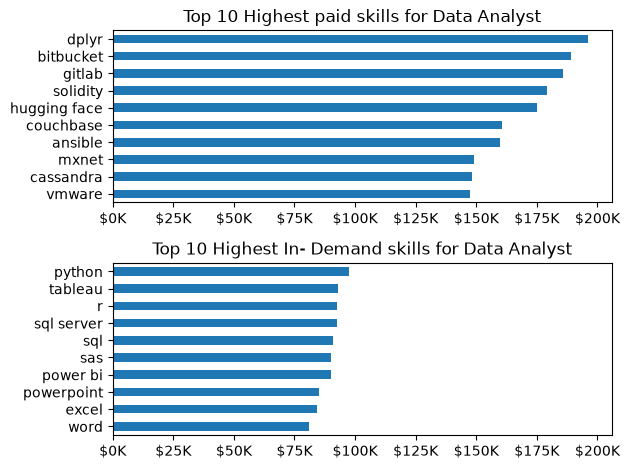

In [5]:
df_DA_US = df_DA_US.explode('job_skills')

df_DA_top_pay = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='median', ascending= False)
df_DA_top_pay = df_DA_top_pay.head(10)

df_DA_skills = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending= False)
df_DA_skills = df_DA_skills.head(10).sort_values(by='median', ascending=False)

fig, ax = plt.subplots(2, 1)

df_DA_top_pay[::-1].plot(kind='barh', y= 'median', ax=ax[0], legend=False)
ax[0].set_title('Top 10 Highest paid skills for Data Analyst')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x , _: f'${int(x/1000)}K'))

df_DA_skills[::-1].plot(kind='barh', y= 'median', ax=ax[1], legend= False)
ax[1].set_title('Top 10 Highest In- Demand skills for Data Analyst')
ax[1].set_ylabel('')
ax[1].set_xlabel('')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x , _: f'${int(x/1000)}K'))

fig.tight_layout()
plt.show()

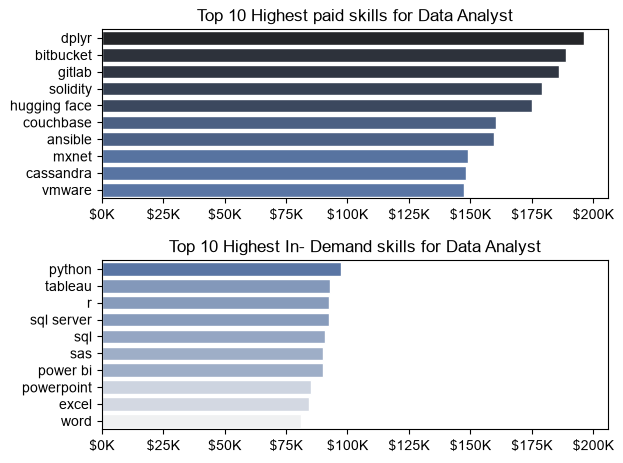

In [13]:
fig, ax = plt.subplots(2, 1)

sns.set_theme(style='ticks')

sns.barplot(data=df_DA_top_pay, x= 'median', y=df_DA_top_pay.index, ax=ax[0], hue='median',palette='dark:b_r')
ax[0].legend().remove()

#df_DA_top_pay[::-1].plot(kind='barh', y= 'median', ax=ax[0], legend=False)
ax[0].set_title('Top 10 Highest paid skills for Data Analyst')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x , _: f'${int(x/1000)}K'))


sns.barplot(data=df_DA_skills, x= 'median', y=df_DA_skills.index, ax=ax[1],hue='median', palette='light:b')
ax[1].legend().remove()
#df_DA_skills[::-1].plot(kind='barh', y= 'median', ax=ax[1], legend= False)
ax[1].set_title('Top 10 Highest In- Demand skills for Data Analyst')
ax[1].set_ylabel('')
ax[1].set_xlabel('')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x , _: f'${int(x/1000)}K'))

fig.tight_layout()
plt.show()

Text(0, 0.5, 'Number od Jobs')

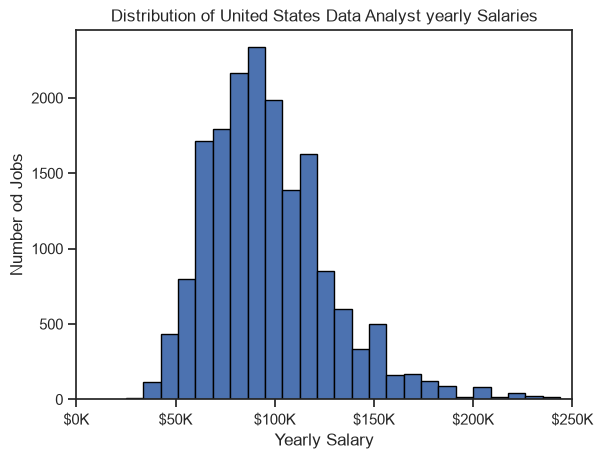

In [14]:
df_DA_US[ 'salary_year_avg'].plot(kind='hist', bins=40, edgecolor='black')
plt.xlim(0,250000)

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x , pos:f'${int(x/1000)}K'))
plt.title('Distribution of United States Data Analyst yearly Salaries')
plt.xlabel ('Yearly Salary')
plt.ylabel ('Number od Jobs')

Text(12.444444444444445, 0.5, 'Number od Jobs')

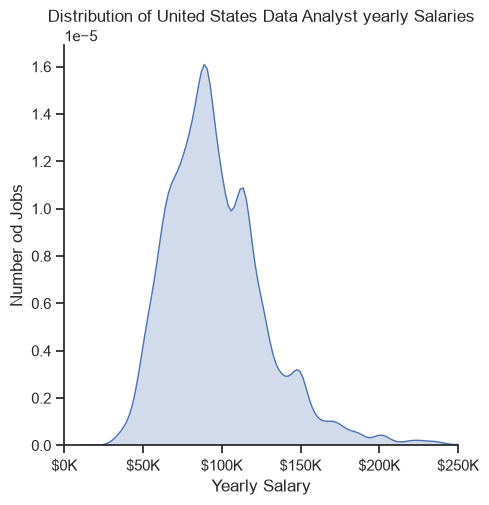

In [17]:
sns.displot(df_DA_US['salary_year_avg'],kind='kde', fill=True)

plt.xlim(0,250000)

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x , pos:f'${int(x/1000)}K'))
plt.title('Distribution of United States Data Analyst yearly Salaries')
plt.xlabel ('Yearly Salary')
plt.ylabel ('Number od Jobs')

C:\Users\moham\AppData\Local\Temp\ipykernel_13968\1101612201.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(job_list, label= job_titles, vert=False)


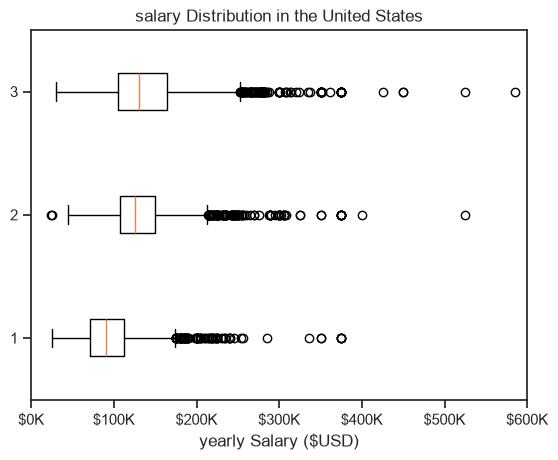

In [18]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_US = df[
    (df['job_title_short'].isin(job_titles)) &
    (df['job_country'] == 'United States')
].copy()

df_US = df_US.dropna(subset=['salary_year_avg'])
job_list = [df_US[df_US['job_title_short']==job_title]['salary_year_avg'] for job_title in job_titles]

plt.boxplot(job_list, label= job_titles, vert=False)
plt.title ('salary Distribution in the United States')
plt.xlabel('yearly Salary ($USD)')
ax= plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.xlim(0, 600000)
plt.show()


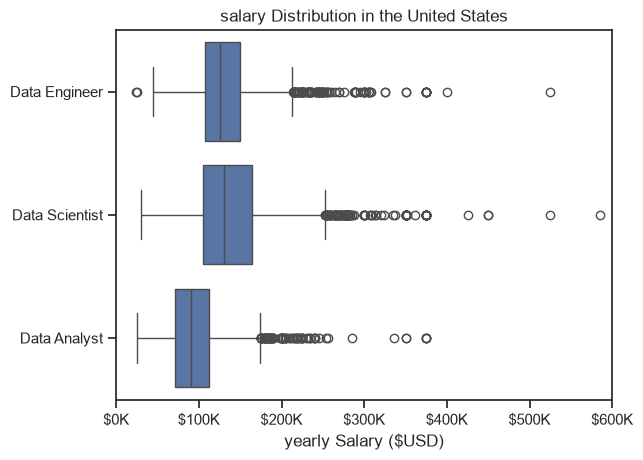

In [22]:
sns.boxplot(data=df_US, x= 'salary_year_avg', y='job_title_short')

plt.title ('salary Distribution in the United States')
plt.xlabel('yearly Salary ($USD)')
plt.ylabel('')
ax= plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.xlim(0, 600000)
plt.show()